Problem statement



A construction project involves three tasks:

Task 1 is likely to take three days (70% probability), but it might also be completed in two days (with 10% probability) or four days (20% probability)

Task 2 has a 60% probability of taking six days to finish, a 20% probability each of being completed in five days or eight days

Task 3 has an 80% probability of being completed in four days, 5% probability of being completed in three days and a 15% probability of being completed in five days.

Each task is dependent on the task before it, meaning that the three tasks must be executed in sequence. Your task is to provide information to the project manager concerning the expected completion time of the project and possible delays.

In [2]:
from mpmath import iv #mpmath support interval arithmetic
# Obtain the best and worst cases
task1 = iv.mpf([2, 4])
task2 = iv.mpf([5, 8])
task3 = iv.mpf([3, 5])
task1 + task2 + task3

mpi('10.0', '17.0')

The best case completion time is 10 days, and the worst case is 17 days

# Monte Carlo stochastic simulation

In [5]:
#Simulate Task 1
import numpy
import matplotlib.pyplot as plt
plt.style.use("bmh")
%config InlineBackend.figure_formats=["svg"]

def task1_days() -> int:
    u = numpy.random.uniform()
    if u < 0.7: return 3
    if u < 0.8: return 2
    return 4

In [6]:
task1_days()

3

C:\Users\HomePC\anaconda3\lib\site-packages\ipykernel_launcher.py:5: UserWarning: In Matplotlib 3.3 individual lines on a stem plot will be added as a LineCollection instead of individual lines. This significantly improves the performance of a stem plot. To remove this warning and switch to the new behaviour, set the "use_line_collection" keyword argument to True.
  """


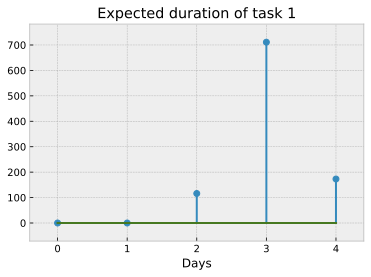

In [7]:
N = 1000
sim = numpy.zeros(N, dtype=int)
for i in range(N):
    sim[i] = task1_days()
plt.stem(numpy.bincount(sim))
plt.title("Expected duration of task 1")
plt.xlabel("Days")
plt.margins(0.1)

In [8]:
#Defining for tasks 2 and 3.def task2_days() -> int:

def task2_days() -> int:
    u = numpy.random.uniform()
    if u < 0.6: return 6
    if u < 0.8: return 5
    return 8

def task3_days() -> int:
    u = numpy.random.uniform()
    if u < 0.8: return 4
    if u < 0.85: return 3
    return 5

In [9]:
# The total duration of the project is simply the sum of the individual task durations.
def project_duration() -> int:
    return task1_days() + task2_days() + task3_days()

Worst case: 17 days
Best case: 10 days
Completion Time: 13.0 days


C:\Users\HomePC\anaconda3\lib\site-packages\ipykernel_launcher.py:5: UserWarning: In Matplotlib 3.3 individual lines on a stem plot will be added as a LineCollection instead of individual lines. This significantly improves the performance of a stem plot. To remove this warning and switch to the new behaviour, set the "use_line_collection" keyword argument to True.
  """


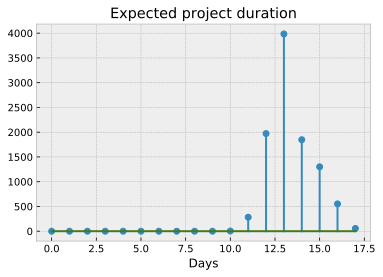

In [11]:
N = 10_000
sim = numpy.zeros(N, dtype=int)
for i in range(N):
    sim[i] = project_duration()
plt.stem(numpy.bincount(sim))
plt.title("Expected project duration")
plt.xlabel("Days");
print("Worst case: {} days".format(sim.max()))
print("Best case: {} days".format(sim.min()))
print("Completion Time: {} days".format(numpy.median(sim)))